# DSS Availability - Monthly Progression

Author: Erick Chauke

Date: May 2026

This notebook turns the monthly availability workbook into one slide-ready chart: each service's monthly availability from April to the latest month, with year-to-date shown alongside. Per-service targets differ and are deliberately left off the chart. It is built section by section, run in VS Code one cell at a time.

## Setup and config

Everything downstream reads from the single config cell below. To point this notebook at a different workbook, change only that cell and run all. The cell after it loads the libraries and resolves the paths.

In [1]:
# CONFIG - the only cell you edit to point at a different dataset
DATA_FILE = "data/availability.xlsx"   # source workbook (gitignored)
YEAR_SHEET = None                       # fiscal-year sheet to chart; None = latest sheet
OUTPUT_DIR = "outputs"                  # where the slide image is saved
ROLLING_MONTHS = 12                     # how many trailing months the tile view shows
Y_AXIS_PAD = 0.5                        # percentage points of headroom for the columns view


In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

DATA_PATH = Path(DATA_FILE)
OUT_PATH = Path(OUTPUT_DIR)
OUT_PATH.mkdir(exist_ok=True)
STEM = DATA_PATH.stem

print("pandas", pd.__version__)
print("data file:", DATA_PATH, "| exists:", DATA_PATH.exists())
print("output dir:", OUT_PATH.resolve())


pandas 2.2.3
data file: data\availability.xlsx | exists: True
output dir: D:\2026\Eskom\DSS availability\availability-visualiser\outputs


## Data ingestion and inspection

The workbook holds one sheet per fiscal year plus a couple of helper sheets. This section discovers the fiscal-year sheets, selects the one to chart (the config value, or the latest year by default), and reads it with no assumed header so we can locate the summary and history blocks ourselves. The raw frame is printed so the real layout is confirmed before any parsing.

In [3]:
import re

xl = pd.ExcelFile(DATA_PATH)

def fiscal_year_start(name):
    m = re.match(r"(\d{4})-\d{4}", name)
    return int(m.group(1)) if m else None

year_sheets = sorted(
    [s for s in xl.sheet_names if fiscal_year_start(s) is not None],
    key=fiscal_year_start,
)
sheet = YEAR_SHEET or year_sheets[-1]

print("all sheets   :", xl.sheet_names)
print("year sheets  :", year_sheets)
print("charting     :", sheet)

raw = pd.read_excel(DATA_PATH, sheet_name=sheet, header=None, na_values=["NULL", "None"])
print("raw shape    :", raw.shape)
print("current month:", raw.iloc[0, 1])
raw


all sheets   : ['2020-2021', '2021-2022', '2022-2023 (2)', '2023-2024', '2024-2025', '2025-2026', '2026-2027', 'Sheet1']
year sheets  : ['2020-2021', '2021-2022', '2022-2023 (2)', '2023-2024', '2024-2025', '2025-2026', '2026-2027']
charting     : 2026-2027
raw shape    : (26, 13)
current month: May


,0,1,2,3,4,5,6,7,8,9,10,11,12
0,Month,May,NaN,NaN,NaN,NaN,<--- Change this to get a report for the speci...,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Service,Availability,YTD,Target,Comment,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,Powi,1,1,0.9925,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,Systemops,0.99998,0.99997,0.9925,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,Themis,1,1,0.9925,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,TEMSE HIS,1,0.99999,0.99,NaN,"""http://ncssnagios.eskom.co.za/trends.html""",NaN,NaN,NaN,""" with user/passwod: nagiosadmin""",NaN,NaN
6,NaN,TEMSE NCC,0.99995,0.999955,0.99992,NaN,"""http://systemops.eskom.co.za/temse/downtime/""",NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,TEMSE SCC,0.9993,0.9993,0.9992,NaN,"""SCC availability link on http://encweb1e06"" -...",NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,Powi,Powi YTD,Systemops,Systemops YTD,Themis,Themis YTD,TEMSE HIS,HIS YTD,TEMSE NCC,NCC YTD,TEMSE SCC,SCC YTD


## Cleaning and parsing

The history block sits below the summary block in each sheet. We anchor on the April and March month labels to locate it without hard-coding row numbers, pair each service column with the YTD column immediately to its right, and reshape into a tidy long table with one row per service and month. Availability is stored as a fraction in the workbook, so we scale it to a percentage. Numeric coercion is logged. Months with no reading yet (the future months of the current year) are dropped from the monthly series, while the YTD carried in the workbook gives each service its year-to-date figure.

In [4]:
# Locate the history block by anchoring on the April and March month labels
month_labels = raw[0].astype(str).str.strip()
april_idx = month_labels[month_labels == "April"].index[0]
march_idx = month_labels[month_labels == "March"].index[0]
header = raw.iloc[april_idx - 1]

# Pair each service column with the YTD column immediately to its right
service_cols = {}
c = 1
while c < raw.shape[1] and pd.notna(header[c]):
    service_cols[str(header[c]).strip()] = (c, c + 1)
    c += 2

SERVICES = list(service_cols)
print("services:", SERVICES)

# Reshape the month rows into tidy long form, scaling fractions to percentages
hist = raw.iloc[april_idx:march_idx + 1]
months = hist[0].astype(str).str.strip().tolist()

records = []
lost = 0
for svc, (avail_c, ytd_c) in service_cols.items():
    avail = pd.to_numeric(hist[avail_c], errors="coerce")
    ytd = pd.to_numeric(hist[ytd_c], errors="coerce")
    lost += int((avail.isna() & hist[avail_c].notna()).sum())
    lost += int((ytd.isna() & hist[ytd_c].notna()).sum())
    for m, a, y in zip(months, avail, ytd):
        records.append({
            "service": svc,
            "month": m,
            "availability": a * 100 if pd.notna(a) else a,
            "ytd": y * 100 if pd.notna(y) else y,
        })

tidy = pd.DataFrame(records)
tidy["month"] = pd.Categorical(tidy["month"], categories=months, ordered=True)
print("values lost to coercion:", lost)

# Monthly series keeps only months with a real reading; YTD reference is the latest one
monthly = tidy.dropna(subset=["availability"]).copy()
filled_months = monthly["month"].cat.remove_unused_categories().cat.categories.tolist()
latest_month = filled_months[-1]
ytd_now = tidy[tidy["month"] == latest_month].set_index("service")["ytd"]

print("filled months:", filled_months)
print("latest month :", latest_month)
print()
print("current year to date by service:")
print(ytd_now.to_string())

# Per-service targets from the summary block, used for the target line
summary_labels = raw[1].astype(str).str.strip()
summary_hdr = summary_labels[summary_labels == "Service"].index[0]
targets = {}
r = summary_hdr + 1
while r < raw.shape[0] and pd.notna(raw.iloc[r, 1]) and str(raw.iloc[r, 1]).strip() not in ("", "nan"):
    svc_name = str(raw.iloc[r, 1]).strip()
    t = pd.to_numeric(raw.iloc[r, 4], errors="coerce")
    if pd.notna(t):
        targets[svc_name] = t * 100
    r += 1
    if r - summary_hdr > 8:
        break
print("targets:", targets)

monthly


services: ['Powi', 'Systemops', 'Themis', 'TEMSE HIS', 'TEMSE NCC', 'TEMSE SCC']
values lost to coercion: 0
filled months: ['April', 'May']
latest month : May

current year to date by service:
service
Powi         100.0000
Systemops     99.9970
Themis       100.0000
TEMSE HIS     99.9990
TEMSE NCC     99.9955
TEMSE SCC     99.9300
targets: {'Powi': 99.25, 'Systemops': 99.25, 'Themis': 99.25, 'TEMSE HIS': 99.0, 'TEMSE NCC': 99.992, 'TEMSE SCC': 99.92}


,service,month,availability,ytd
0,Powi,April,100.000,100.0000
1,Powi,May,100.000,100.0000
12,Systemops,April,99.996,99.9960
13,Systemops,May,99.998,99.9970
24,Themis,April,100.000,100.0000
25,Themis,May,100.000,100.0000
36,TEMSE HIS,April,99.998,99.9980
37,TEMSE HIS,May,100.000,99.9990
48,TEMSE NCC,April,99.996,99.9960
49,TEMSE NCC,May,99.995,99.9955


## Visualisation

One figure, an executive tile grid with a panel per service, sized for a single slide. Each tile shows a rolling twelve months so the trend is visible rather than flat: the blue line is monthly availability, the orange dashed line is the year to date, and the grey dashed line is that service's target. Any month below target is marked in red. A vertical line marks where the new financial year starts in April, and the year to date resets across it. Tiles are ordered by the current month, lowest first, so whatever needs attention leads. The vertical axis never goes above 100 percent and each tile scales its own lower bound so a dip stays visible. The rolling length is set in the config cell, and the latest sheet, month and window are all detected from the workbook. The figure is saved to the outputs folder under the source file stem.

saved outputs\availability_monthly_availability.png


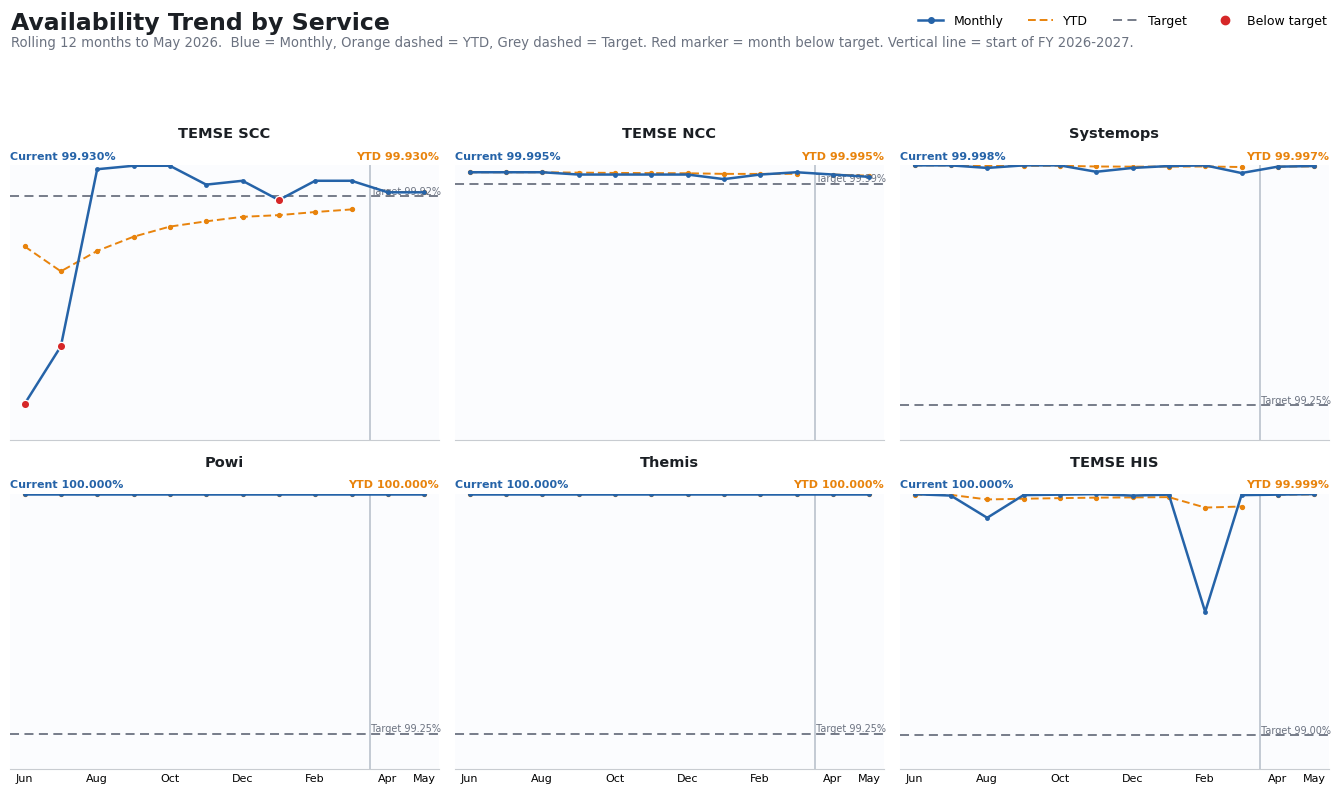

In [5]:
import re, math

# Stitch every fiscal-year sheet into one continuous monthly timeline
MONTH_NUM = {"April": 4, "May": 5, "June": 6, "July": 7, "August": 8, "September": 9,
             "October": 10, "November": 11, "December": 12, "January": 1, "February": 2, "March": 3}


def fy_start(name):
    m = re.match(r"(\d{4})-\d{4}", name)
    return int(m.group(1)) if m else None


def cal_year(fy_first, month):
    return fy_first if MONTH_NUM[month] >= 4 else fy_first + 1


xl = pd.ExcelFile(DATA_PATH)
all_sheets = sorted([s for s in xl.sheet_names if fy_start(s) is not None], key=fy_start)
rows = []
for sh_name in all_sheets:
    rw = pd.read_excel(DATA_PATH, sheet_name=sh_name, header=None, na_values=["NULL", "None"])
    ml = rw[0].astype(str).str.strip()
    if not (ml == "April").any():
        continue
    ai = ml[ml == "April"].index[0]
    mi = ml[ml == "March"].index[0]
    hd = rw.iloc[ai - 1]
    sc, c = {}, 1
    while c < rw.shape[1] and pd.notna(hd[c]):
        sc[str(hd[c]).strip()] = (c, c + 1)
        c += 2
    block = rw.iloc[ai:mi + 1]
    mnames = block[0].astype(str).str.strip().tolist()
    fyf = fy_start(sh_name)
    for svc, (acol, ycol) in sc.items():
        av = pd.to_numeric(block[acol], errors="coerce")
        yt = pd.to_numeric(block[ycol], errors="coerce")
        for mm, a, y in zip(mnames, av, yt):
            rows.append(dict(service=svc, fy=sh_name, month=mm,
                             date=pd.Timestamp(cal_year(fyf, mm), MONTH_NUM[mm], 1),
                             availability=a * 100 if pd.notna(a) else None,
                             ytd=y * 100 if pd.notna(y) else None))
roll_df = pd.DataFrame(rows)

# Trailing window of ROLLING_MONTHS ending at the latest filled month
filled = roll_df.dropna(subset=["availability"])
latest_date = filled["date"].max()
window_months = sorted([d for d in filled["date"].unique() if d <= latest_date])[-ROLLING_MONTHS:]
window_months = list(pd.to_datetime(window_months))

current_sheet = sheet  # auto-selected latest sheet from the ingestion cell
fy_first = fy_start(current_sheet)
new_fy_april = pd.Timestamp(fy_first, 4, 1)
april_idx = next((i for i, d in enumerate(window_months) if d == new_fy_april), None)

# Per-service series over the window
tile_data = {}
for svc in SERVICES:
    sd = roll_df[roll_df["service"] == svc].set_index("date")
    mvals = [sd.loc[d, "availability"] if d in sd.index else None for d in window_months]
    yvals = [sd.loc[d, "ytd"] if d in sd.index else None for d in window_months]
    cur = next((v for v in reversed(mvals) if v is not None), None)
    ytdc = next((v for v in reversed(yvals) if v is not None), None)
    tile_data[svc] = dict(mvals=mvals, yvals=yvals, current=cur, ytd=ytdc, target=targets.get(svc))

order = sorted(SERVICES, key=lambda s: (tile_data[s]["current"] if tile_data[s]["current"] is not None else 999))

# Palette
MONTH_C = "#2563a8"
YTD_C = "#e8830c"
BELOW_C = "#d62728"
TARGET_C = "#6b7280"
INK = "#1b1f24"
MUTED = "#6b7280"
PANEL_BG = "#fbfcfe"

n = len(window_months)
x = list(range(n))
labels = [d.strftime("%b") for d in window_months]
show = [i for i in range(n) if i % 2 == 0]
if (n - 1) not in show:
    show.append(n - 1)

ncols = 3
nrows = math.ceil(len(SERVICES) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(13.5, 7.8))
fig.patch.set_facecolor("white")
axes = axes.ravel()

for pos, (ax, svc) in enumerate(zip(axes, order)):
    d = tile_data[svc]
    ax.set_facecolor(PANEL_BG)
    row = pos // ncols
    tgt = d["target"]

    if april_idx is not None:
        ax.axvline(april_idx - 0.5, color="#b9c2cc", linewidth=1.2, zorder=1)
    if tgt is not None:
        ax.axhline(tgt, color=TARGET_C, linestyle=(0, (5, 3)), linewidth=1.3, zorder=2)

    # year to date, reset at the April boundary
    groups = [range(0, april_idx), range(april_idx, n)] if april_idx is not None else [range(0, n)]
    for grp in groups:
        xs = [x[i] for i in grp if d["yvals"][i] is not None]
        ys = [d["yvals"][i] for i in grp if d["yvals"][i] is not None]
        if xs:
            ax.plot(xs, ys, color=YTD_C, linestyle=(0, (4, 2)), linewidth=1.4,
                    marker="o", markersize=2.8, zorder=3)

    # monthly line, with below-target months in red
    mx = [x[i] for i in range(n) if d["mvals"][i] is not None]
    my = [d["mvals"][i] for i in range(n) if d["mvals"][i] is not None]
    ax.plot(mx, my, color=MONTH_C, linewidth=1.8, zorder=4)
    for i in range(n):
        v = d["mvals"][i]
        if v is None:
            continue
        below = tgt is not None and v < tgt
        ax.plot([x[i]], [v], "o", markersize=6 if below else 3.5,
                color=BELOW_C if below else MONTH_C,
                markeredgecolor="white", markeredgewidth=0.9 if below else 0,
                zorder=6 if below else 4)

    vals = [v for v in d["mvals"] + d["yvals"] if v is not None]
    floor = min(vals + ([tgt] if tgt is not None else []))
    ymin = floor - ((100 - floor) * 0.12 + 0.02)
    if 100 - ymin < 0.12:
        ymin = 100 - 0.12
    ax.set_ylim(ymin, 100)
    ax.set_xlim(-0.4, n - 0.6)

    # current and year-to-date callouts sit above the plot so they never cross the line
    ax.set_title(svc, fontsize=10.5, fontweight="bold", color=INK, pad=20)
    ax.text(0.0, 1.015, f"Current {d['current']:.3f}%", transform=ax.transAxes,
            fontsize=8, fontweight="bold", color=MONTH_C, va="bottom", ha="left")
    ax.text(1.0, 1.015, f"YTD {d['ytd']:.3f}%", transform=ax.transAxes,
            fontsize=8, fontweight="bold", color=YTD_C, va="bottom", ha="right")
    if tgt is not None:
        ax.text(n - 0.55, tgt, f" Target {tgt:.2f}%", fontsize=7, color=TARGET_C,
                va="bottom", ha="right")

    ax.set_yticks([])
    ax.grid(axis="y", color="#eef1f5", linewidth=0.7, zorder=0)
    ax.set_xticks([x[i] for i in show])
    if row == nrows - 1:
        ax.set_xticklabels([labels[i] for i in show], fontsize=8)
    else:
        ax.set_xticklabels([])
    ax.tick_params(length=0)
    for sp in ("top", "right", "left"):
        ax.spines[sp].set_visible(False)
    ax.spines["bottom"].set_color("#c8ccd1")

for ax in axes[len(SERVICES):]:
    ax.set_visible(False)

fig.suptitle("Availability Trend by Service", x=0.012, y=1.01, ha="left",
             fontsize=17, fontweight="bold", color=INK)
fig.text(0.012, 0.965,
         f"Rolling {ROLLING_MONTHS} months to {window_months[-1].strftime('%b %Y')}.  "
         f"Blue = Monthly, Orange dashed = YTD, Grey dashed = Target. "
         f"Red marker = month below target. Vertical line = start of FY {current_sheet}.",
         ha="left", fontsize=9.5, color=MUTED)

handles = [
    plt.Line2D([], [], color=MONTH_C, marker="o", linewidth=1.8, markersize=4, label="Monthly"),
    plt.Line2D([], [], color=YTD_C, linestyle=(0, (4, 2)), linewidth=1.4, label="YTD"),
    plt.Line2D([], [], color=TARGET_C, linestyle=(0, (5, 3)), linewidth=1.3, label="Target"),
    plt.Line2D([], [], color=BELOW_C, marker="o", linestyle="", markersize=6, label="Below target"),
]
fig.legend(handles=handles, loc="upper right", ncol=4, frameon=False, fontsize=9,
           bbox_to_anchor=(0.995, 1.02))

fig.tight_layout(rect=[0.0, 0.0, 1, 0.93])
fig_path = OUT_PATH / f"{STEM}_monthly_availability.png"
fig.savefig(fig_path, dpi=170, bbox_inches="tight", facecolor="white")
print("saved", fig_path)
plt.show()


### What the tile view shows

With a rolling twelve months in view the lines finally carry their shape. Each tile runs from the same month last year to the latest, the vertical line marks where the new financial year begins in April, and the grey dashed line is that service's target. Any month below target is picked out in red. TEMSE SCC tells the clearest story: it opened the window below its 99.92 percent target in the winter months, in red, then recovered and has held above target since. TEMSE HIS dipped sharply in February but stayed above its 99.0 percent target, so it is not flagged, which is exactly the single-month event the rolling view keeps visible. The steady services, Powi, Themis and Systemops, sit far above their 99.25 percent target across the whole window. Ordering the tiles by the current month keeps whatever needs attention in the top left.

## Alternative view: grouped columns

A second take on the same data for comparison, so the chart style can be chosen on its merits. Services sit along the bottom; within each service a column is drawn for every month from April to the latest, the value is printed on each column because the services run so close together, and the red diamond marks the year to date. It reads cleanly for a few months and gets busier as the year fills out. This figure is saved to the outputs folder under its own name so it does not overwrite the panel view.

saved outputs\availability_monthly_availability_columns.png


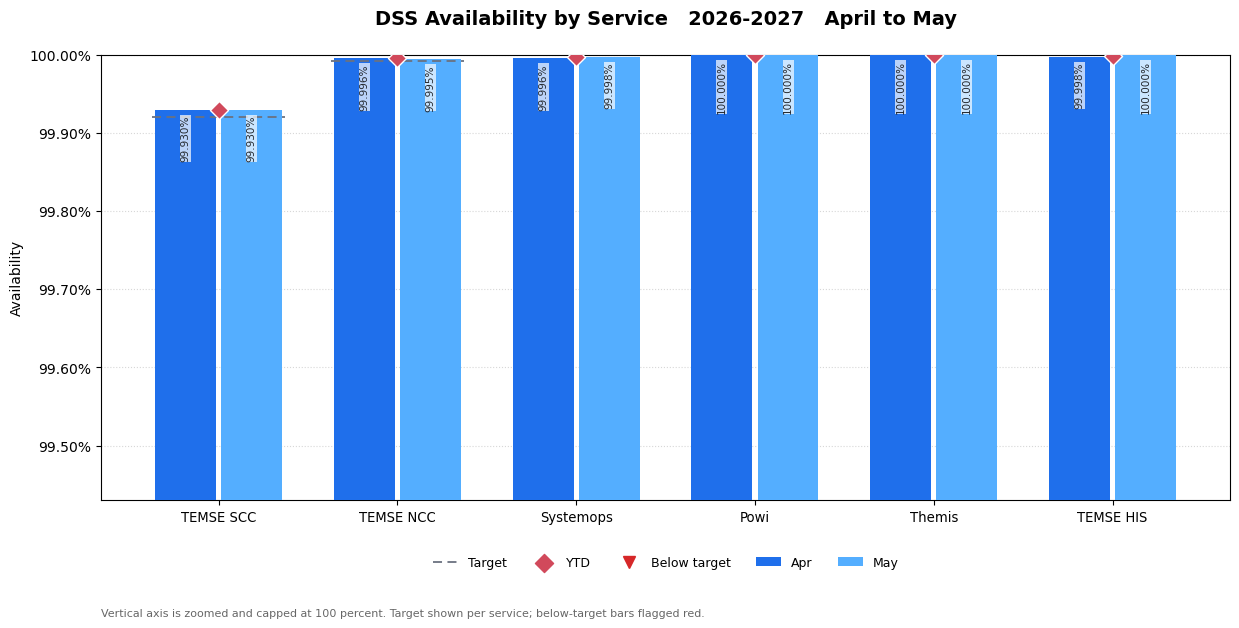

In [6]:
# Months in shades of blue, year to date as a red diamond. Services follow the tile order.
COL_MONTH_COLORS = ["#1f6feb", "#54aeff", "#a5d6ff"]
COL_YTD = "#d1495b"
COL_TARGET = "#6b7280"
COL_BELOW = "#d62728"
col_services = order  # same order as the tile view, most interesting first

all_vals = pd.concat([monthly["availability"], ytd_now]).dropna()
ymin = all_vals.min() - Y_AXIS_PAD
ymax = 100  # never above 100 percent

fig, ax = plt.subplots(figsize=(12.5, 6.8))
fig.patch.set_facecolor("white")
n = len(filled_months)
group_w = 0.74
bar_w = group_w / n
base = list(range(len(col_services)))
label_box = dict(facecolor="white", alpha=0.7, edgecolor="none", pad=0.4)

for j, m in enumerate(filled_months):
    vals = [monthly[(monthly["service"] == s) & (monthly["month"] == m)]["availability"].values[0]
            for s in col_services]
    offs = [b - group_w / 2 + bar_w / 2 + j * bar_w for b in base]
    ax.bar(offs, vals, width=bar_w * 0.92, color=COL_MONTH_COLORS[j % len(COL_MONTH_COLORS)],
           label=str(m)[:3], zorder=3)
    for xo, v, s in zip(offs, vals, col_services):
        ax.annotate(f"{v:.3f}%", (xo, v), textcoords="offset points", xytext=(0, -4),
                    ha="center", va="top", rotation=90, fontsize=7.5, color="#24292f",
                    bbox=label_box, zorder=5)
        # flag a bar that sits below its target
        tgt = targets.get(s)
        if tgt is not None and v < tgt:
            ax.plot([xo], [v], marker="v", color=COL_BELOW, markersize=8,
                    markeredgecolor="white", markeredgewidth=0.8, zorder=6)

# target as a short line across each service group
for b, s in zip(base, col_services):
    tgt = targets.get(s)
    if tgt is not None:
        ax.hlines(tgt, b - group_w / 2, b + group_w / 2, color=COL_TARGET,
                  linestyle=(0, (5, 3)), linewidth=1.3, zorder=4)
    ax.scatter([b], [ytd_now[s]], marker="D", s=85, color=COL_YTD, zorder=4,
               edgecolor="white", linewidth=1)

ax.plot([], [], color=COL_TARGET, linestyle=(0, (5, 3)), linewidth=1.3, label="Target")
ax.scatter([], [], marker="D", s=85, color=COL_YTD, label="YTD")
ax.plot([], [], marker="v", color=COL_BELOW, linestyle="", markersize=8, label="Below target")

ax.set_xticks(base)
ax.set_xticklabels(col_services, fontsize=9.5)
ax.set_ylim(ymin, ymax)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.2f}%"))
ax.grid(axis="y", linestyle=":", alpha=0.5)
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.18), frameon=False, ncol=n + 3, fontsize=9)
ax.set_title(f"DSS Availability by Service   {sheet}   April to {latest_month}",
             fontsize=14, fontweight="bold", pad=22)
ax.set_ylabel("Availability")
ax.text(0.0, -0.26, "Vertical axis is zoomed and capped at 100 percent. Target shown per service; below-target bars flagged red.",
        transform=ax.transAxes, fontsize=8, color="#666666")
fig.tight_layout()
fig.subplots_adjust(top=0.88)

fig_path_columns = OUT_PATH / f"{STEM}_monthly_availability_columns.png"
fig.savefig(fig_path_columns, dpi=170, bbox_inches="tight", facecolor="white")
print("saved", fig_path_columns)
plt.show()


### What the columns view shows

The same services as a straight comparison for the current financial year, with each service's target drawn across its group and any bar below target flagged in red. Right now every service is above target for April and May, so no bars are flagged, and the value printed on each bar carries the detail the heights cannot. This view answers how the services compare this month at a glance, while the tile view above carries the rolling trend. Both are capped at 100 percent.

## Summary and observations

This notebook reads the DSS availability workbook, stitches the fiscal-year sheets into one continuous monthly timeline, and presents a rolling twelve month view of each service with its year to date and its target. Two chart styles are produced: an executive tile view, one panel per service showing the rolling trend, the target line, the new financial year marker and any month below target in red; and a grouped columns view for the current year comparison. Neither draws above 100 percent, and both are sized for a single slide.

Findings for the twelve months to May 2026:

- Five of the six services sit comfortably above their targets across the whole window. Powi, Themis and Systemops run at or near 100 percent against a 99.25 percent target, and TEMSE NCC holds just above its 99.992 percent target.
- TEMSE SCC is the service that has been tested. It opened the window below its 99.92 percent target in the winter months, shown in red, then recovered and has held above target into the new financial year. It still carries the lowest current value, so it leads the tiles.
- TEMSE HIS took a sharp one month dip in February but stayed above its 99.0 percent target, so it is not flagged. It is the kind of single month event the rolling view is designed to keep visible.

Everything updates from the file. The latest sheet and month are detected automatically, the rolling window and the financial year marker move forward on their own, and the targets are read from the workbook. Running next month's file needs no code changes.

### References

No external references were cited in this notebook. All figures are derived directly from the source workbook in the data folder.